In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
data = pd.read_csv('TSLA.csv')
data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0
3,2019-05-24,39.966000,39.995998,37.750000,38.125999,70683000,0,0.0
4,2019-05-28,38.240002,39.000000,37.570000,37.740002,51564500,0,0.0
...,...,...,...,...,...,...,...,...
753,2022-05-16,767.159973,769.760010,719.090027,724.369995,28699500,0,0.0
754,2022-05-17,747.359985,764.479980,728.849976,761.609985,26745400,0,0.0
755,2022-05-18,744.520020,760.500000,700.809998,709.809998,29270600,0,0.0
756,2022-05-19,707.000000,734.000000,694.109985,709.419983,30098900,0,0.0


- Selecting specific columns

In [19]:
data2 = data[['Date','Close']]
data2

,Date,Close
0,2019-05-21,41.015999
1,2019-05-22,38.546001
2,2019-05-23,39.098000
3,2019-05-24,38.125999
4,2019-05-28,37.740002
...,...,...
753,2022-05-16,724.369995
754,2022-05-17,761.609985
755,2022-05-18,709.809998
756,2022-05-19,709.419983


In [20]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    758 non-null    object 
 1   Close   758 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


Converting Date to a date-time format

In [21]:
data2['Date']= pd.to_datetime(data2['Date'])

/var/folders/n9/xrsn60p14h9cv9mjt3n_9gf00000gp/T/ipykernel_6812/1876011426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['Date']= pd.to_datetime(data2['Date'])


In [22]:
data2

,Date,Close
0,2019-05-21,41.015999
1,2019-05-22,38.546001
2,2019-05-23,39.098000
3,2019-05-24,38.125999
4,2019-05-28,37.740002
...,...,...
753,2022-05-16,724.369995
754,2022-05-17,761.609985
755,2022-05-18,709.809998
756,2022-05-19,709.419983


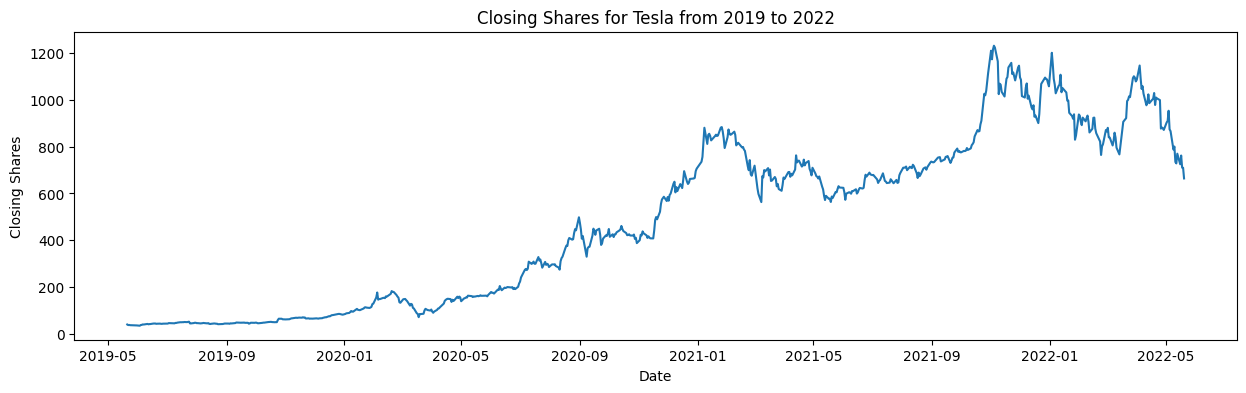

In [23]:
plt.figure(figsize=(15,4))
plt.plot(data2['Date'], data2['Close'])
plt.title("Closing Shares for Tesla from 2019 to 2022")
plt.xlabel("Date")
plt.ylabel("Closing Shares")
plt.show()

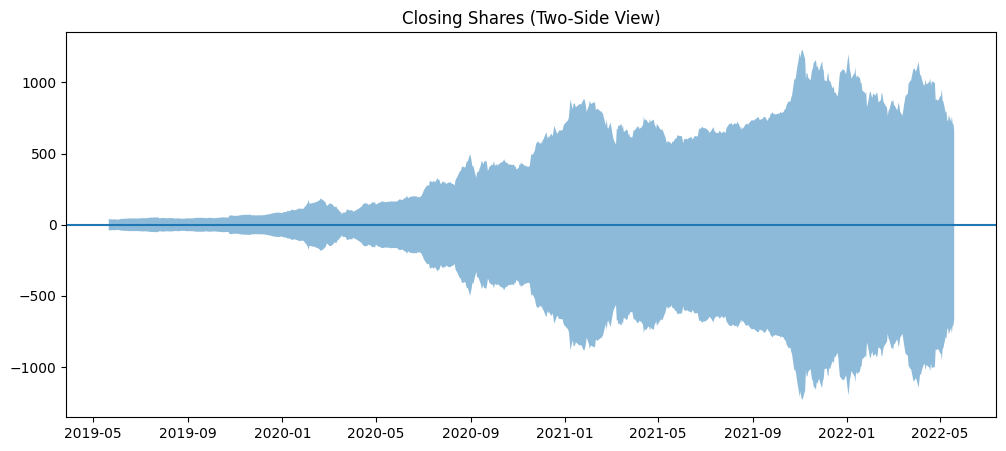

In [24]:
plt.figure(figsize=(12,5))

plt.fill_between(data2['Date'], 
                 data2['Close'], 
                 -data2['Close'], 
                 alpha=0.5)

plt.title("Closing Shares (Two-Side View)")
plt.axhline(0)  # Horizontal line at zero
plt.show()

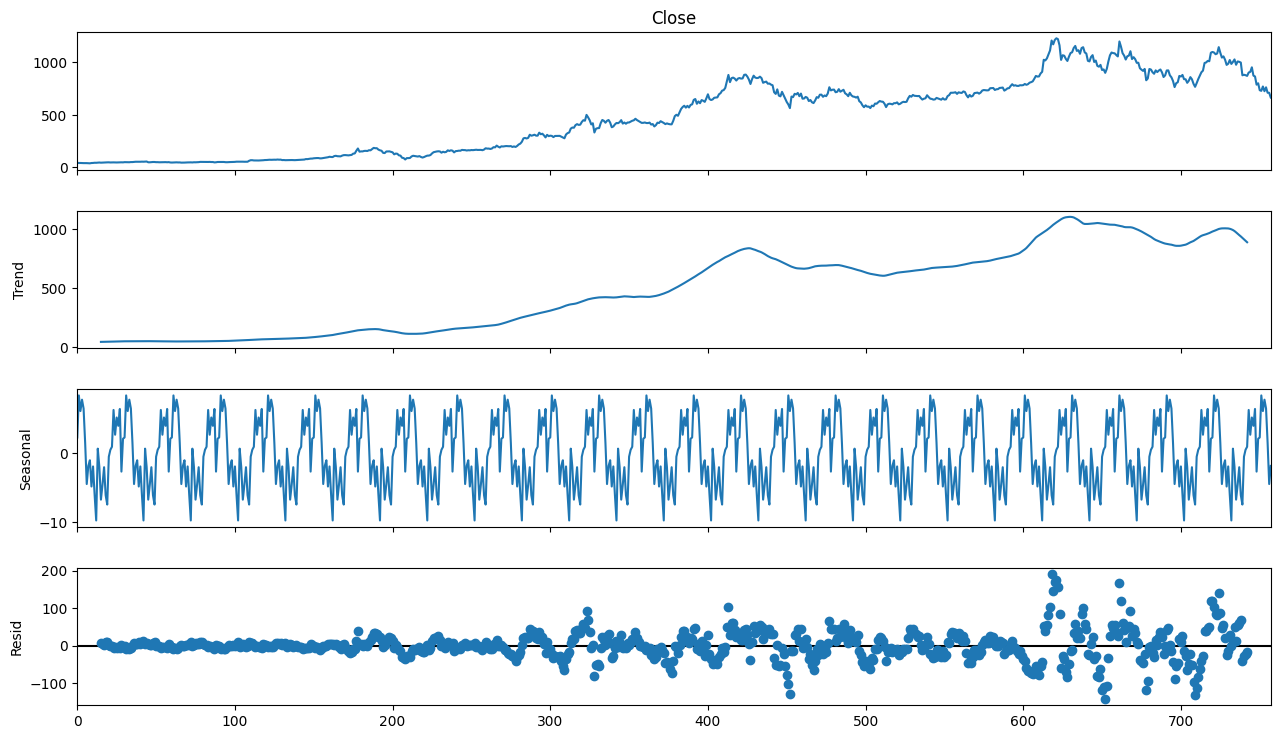

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(data2['Close'], 
                            model='additive', 
                            period=30)

fig = result.plot()
fig.set_size_inches(14, 8)   # Set figure size
plt.show()

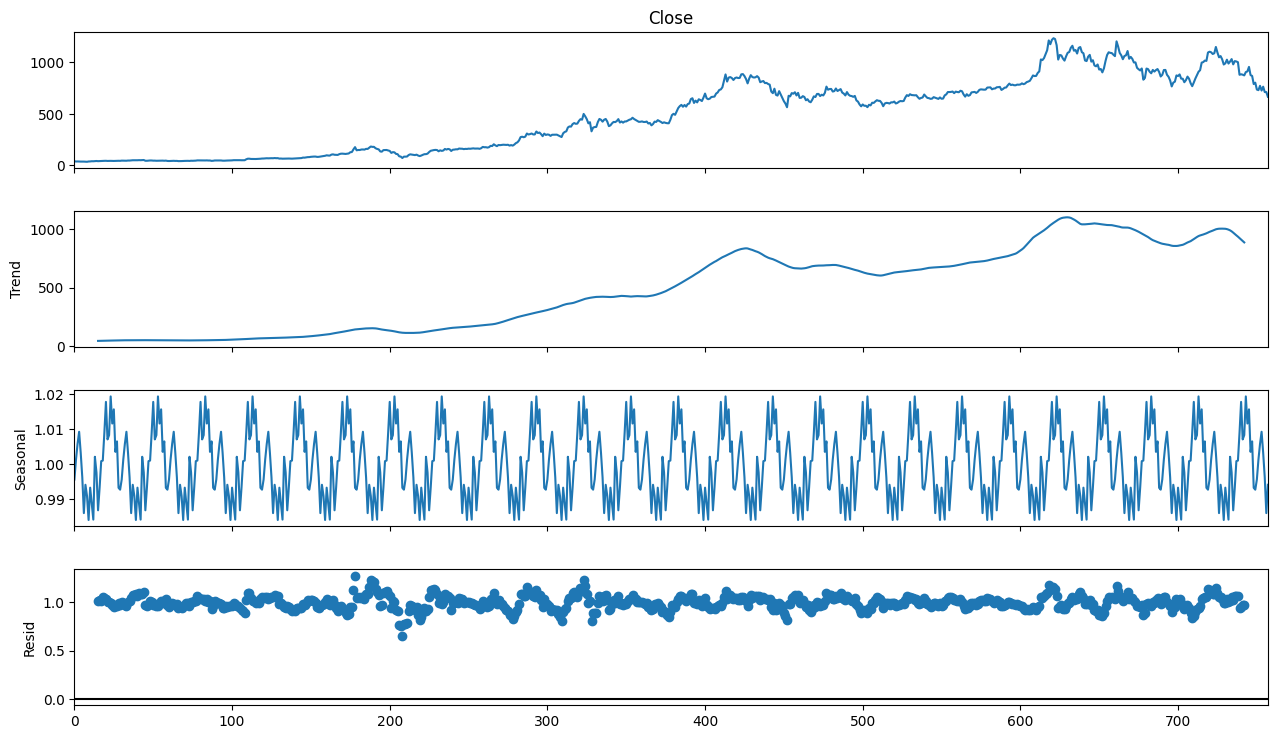

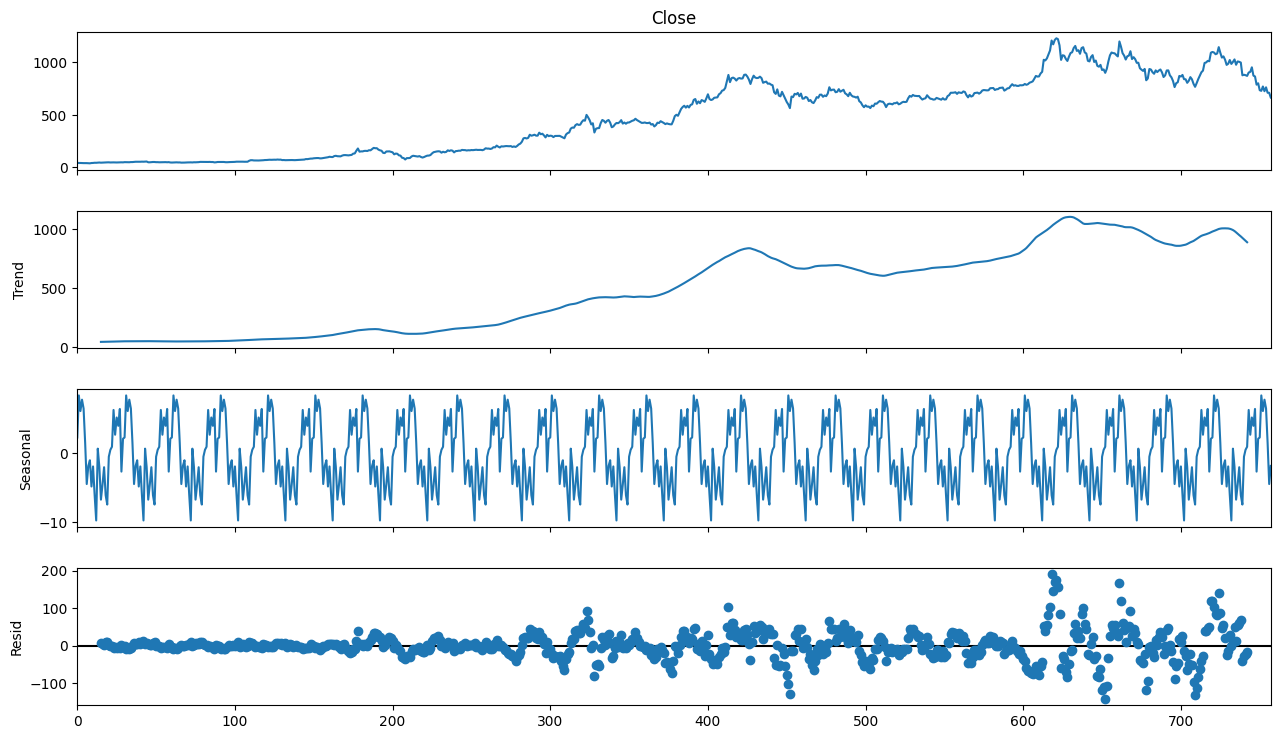

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Multiplicative
multi = seasonal_decompose(data2['Close'], model='multiplicative', period=30)
fig1 = multi.plot()
fig1.set_size_inches(14, 8)
plt.show()

# Additive
add = seasonal_decompose(data2['Close'], model='additive', period=30)
fig2 = add.plot()
fig2.set_size_inches(14, 8)
plt.show()

In [27]:
data2.set_index('Date',inplace=True)


In [28]:
data2.head()

,Close
Date,
2019-05-21,41.015999
2019-05-22,38.546001
2019-05-23,39.098000
2019-05-24,38.125999
2019-05-28,37.740002


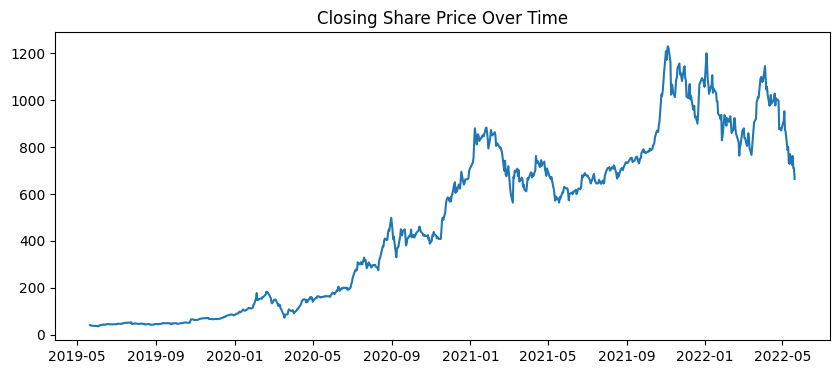

In [29]:
plt.figure(figsize=(10,4))
plt.plot(data2['Close'])
plt.title("Closing Share Price Over Time")
plt.show()